In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', None)

PROCESSED_DATA_DIR = Path("C:\\Users\\aabre\\Documents\\data-science-projects\\nba-player-archetype-clustering\\data\\processed\\2025_26")
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

candidate_features = pd.read_csv(PROCESSED_DATA_DIR / "candidate_features.csv")
candidate_features.head(10)

,PLAYER_ID,PLAYER_NAME,USG_RATE,TOUCHES_PER_100,POT_AST_PER_100,DRIVES_PER_100,CATCH_SHOOT_FGA_PER_100,PULL_UP_FGA_PER_100,3PT_FGA_SHARE,PAINT_TOUCHES_PER_100,POST_TOUCHES_PER_100,SCREEN_AST_PER_100,REB_CHANCES_PER_100,OREB_PCT,DEFLECTIONS,STL_PCT,BLK_PCT,BOXOUTS_PER_100,DEF_LOOSE_BALLS_REC_PER_100,PAINT_FGA_RATE,MIDRANGE_FGA_RATE,FTA_RATE
0,1631260,AJ Green,0.135,62.287415,5.824830,4.591837,8.864796,3.507653,0.896,0.786565,0.000000,0.595238,7.482993,0.013,2.359694,0.111,0.042,0.765306,0.552721,0.061489,0.042071,0.100324
1,1642358,AJ Johnson,0.195,69.834711,10.020661,19.111570,3.719008,2.582645,0.324,2.789256,0.103306,0.309917,8.677686,0.027,2.272727,0.159,0.067,0.103306,0.000000,0.653409,0.022727,0.227273
2,203932,Aaron Gordon,0.213,75.477099,8.158397,6.917939,5.152672,4.532443,0.394,9.112595,3.244275,1.717557,13.215649,0.052,1.288168,0.146,0.130,0.667939,0.429389,0.479899,0.125628,0.409548
3,1628988,Aaron Holiday,0.159,64.338690,7.478368,11.001236,8.961681,3.152040,0.675,0.370828,0.247219,0.370828,5.377009,0.016,2.410383,0.203,0.060,0.432633,0.494438,0.261905,0.063492,0.162698
4,1630174,Aaron Nesmith,0.190,73.040752,5.398816,14.350401,7.871822,4.249390,0.541,1.776385,0.383142,0.940439,9.683037,0.034,1.741553,0.138,0.205,0.383142,0.383142,0.347656,0.111328,0.216797
5,1630598,Aaron Wiggins,0.194,64.434025,6.965841,14.567984,7.032820,3.047555,0.504,2.813128,0.401875,0.602813,10.046885,0.028,3.784327,0.211,0.196,0.569324,0.703282,0.449627,0.046642,0.134328
6,1642846,Ace Bailey,0.210,51.625548,5.602951,10.767812,7.355315,6.963339,0.446,3.850588,0.922297,0.415033,9.499654,0.048,2.559373,0.164,0.302,0.622550,0.322804,0.331839,0.221973,0.098655
7,1641737,Adem Bona,0.108,42.057143,2.247619,1.523810,0.228571,0.038095,0.027,9.447619,0.723810,4.266667,20.076190,0.099,3.123810,0.128,0.466,2.476190,0.685714,0.968182,0.004545,0.513636
8,1642349,Ajay Mitchell,0.210,75.801842,12.765957,24.896793,3.906002,4.033026,0.298,2.000635,0.349317,0.317561,9.145761,0.027,4.096539,0.228,0.113,0.571610,0.698634,0.622034,0.079661,0.274576
9,201143,Al Horford,0.163,88.410758,11.784841,3.471883,10.024450,0.586797,0.633,6.161369,6.552567,2.298289,13.691932,0.043,2.591687,0.144,0.481,1.858191,0.440098,0.317901,0.049383,0.080247


In [49]:
features = candidate_features.drop(["PLAYER_ID", "PLAYER_NAME"], axis=1)
features.describe().T

,count,mean,std,min,25%,50%,75%,max
USG_RATE,450.0,0.184949,0.053039,0.082000,0.146000,0.177000,0.216000,0.368000
TOUCHES_PER_100,450.0,71.670469,18.576337,32.486264,56.959260,68.297520,85.180412,126.370004
POT_AST_PER_100,450.0,8.927243,4.811384,1.762632,5.200479,7.489775,11.595704,25.026069
DRIVES_PER_100,450.0,11.916156,8.052690,0.064537,5.821145,10.466334,16.634416,38.993844
CATCH_SHOOT_FGA_PER_100,450.0,5.512717,2.647516,0.000000,3.780319,5.485175,7.340153,12.477396
PULL_UP_FGA_PER_100,450.0,3.674077,3.486992,0.000000,0.850930,2.704628,5.366718,17.464613
3PT_FGA_SHARE,450.0,0.424222,0.203316,0.000000,0.312000,0.443000,0.554500,0.958000
PAINT_TOUCHES_PER_100,450.0,5.090416,4.587706,0.236035,1.792403,3.492143,6.533690,25.041459
POST_TOUCHES_PER_100,450.0,1.293189,1.837262,0.000000,0.227325,0.585828,1.564111,11.073254
SCREEN_AST_PER_100,450.0,1.556757,1.783882,0.000000,0.407402,0.731132,1.873363,7.767945


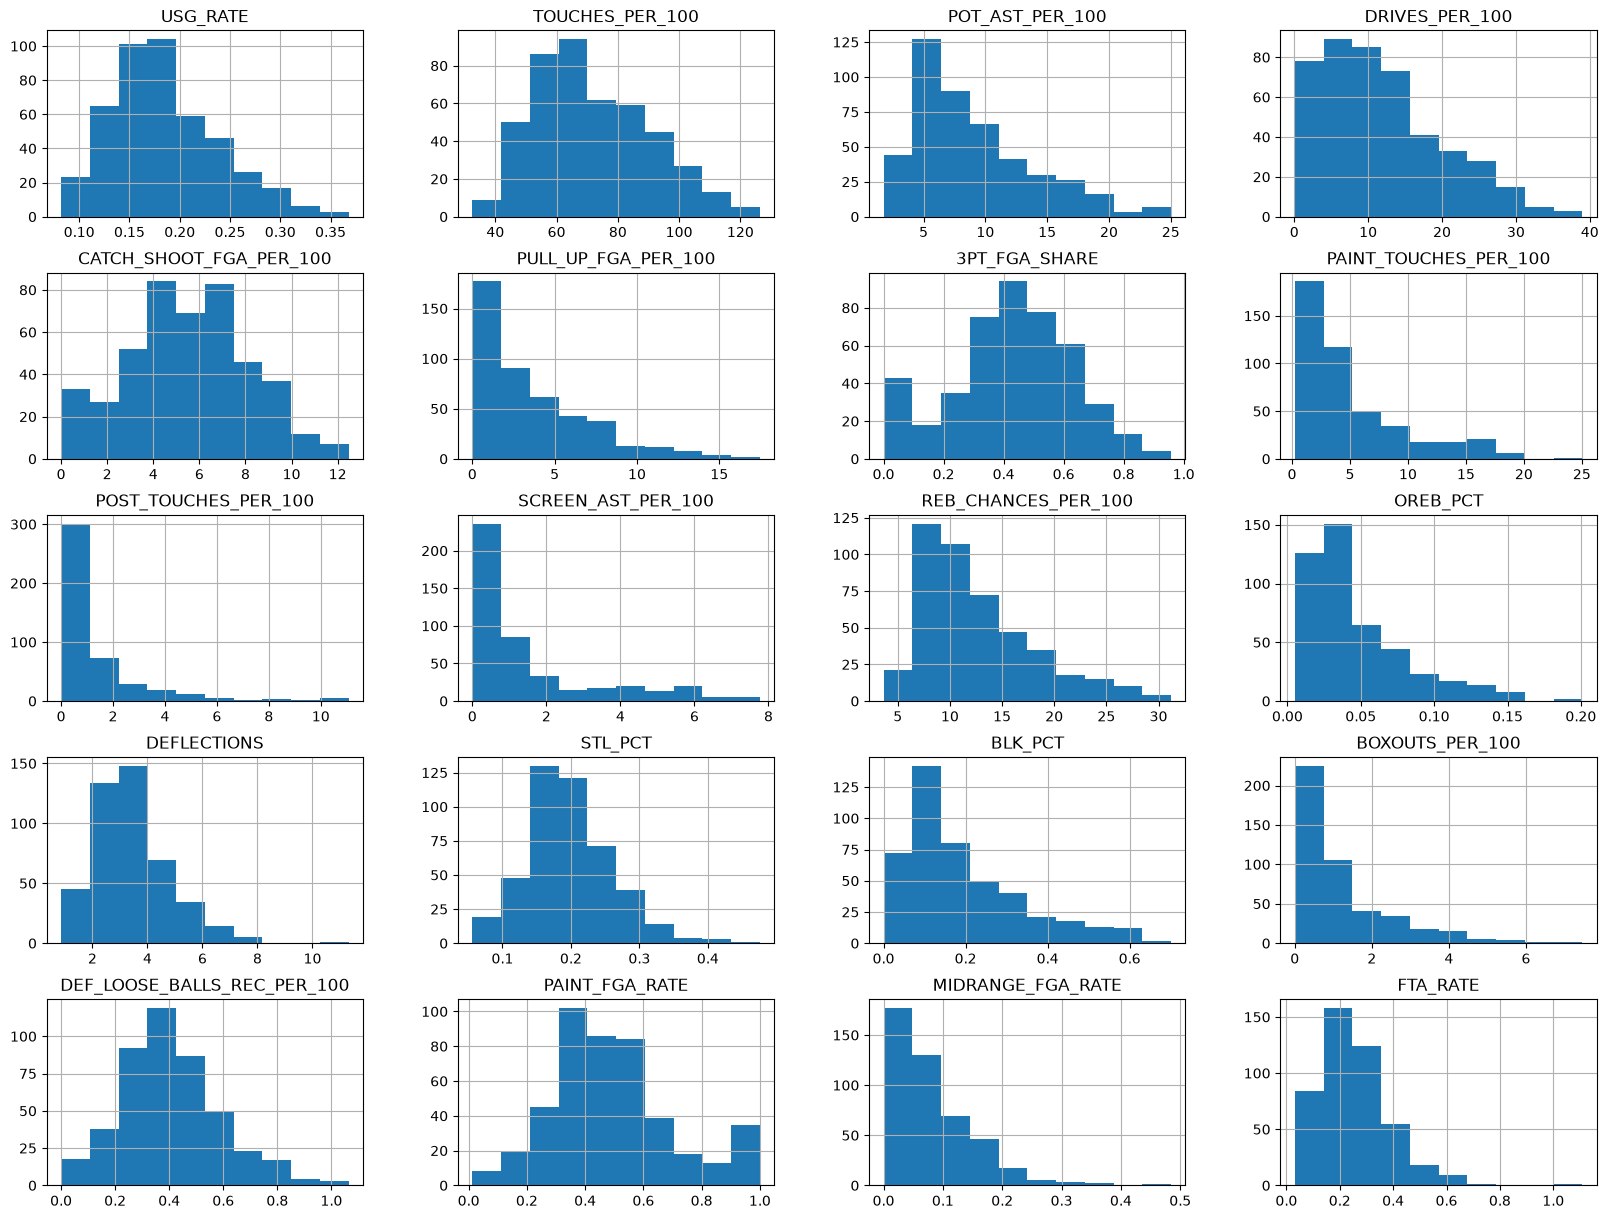

In [50]:
features.hist(figsize=(20, 15), bins=10)

plt.show()

## Feature Distribution Observations

Overall, the candidate style features display a mix of approximately symmetric,
moderately skewed, and highly right-skewed distributions. This is reasonable for
NBA playing-style data because many actions, such as post touches, screen assists,
and blocks, are concentrated among specialized player types rather than being
evenly distributed across the league.

### Offensive Role and Creation

- **USG_RATE:** Usage is unimodal with a moderate right skew. Most players fall
  around the 0.15–0.22 range, while a relatively small number of players have
  usage rates above 0.30. The high-end observations likely represent primary
  offensive creators rather than data errors. The feature has good variation and
  should help distinguish high-usage creators from lower-usage role players.

- **TOUCHES_PER_100:** Touches per 100 possessions is approximately unimodal with
  a slight right skew. Most players appear between roughly 50 and 85 touches per
  100 possessions, with a smaller group exceeding 100. The upper tail likely
  represents players with significant ball-handling or offensive-hub
  responsibilities. This appears to be a useful measure of ball involvement.

- **POT_AST_PER_100:** Potential assists are strongly right-skewed. Most players
  generate relatively few potential assists, while a smaller group reaches much
  higher values. This pattern is consistent with NBA roles, where primary guards
  and playmakers account for a disproportionate share of shot creation for
  teammates. The feature should be valuable for identifying playmaking roles.

- **DRIVES_PER_100:** Drives per 100 possessions is right-skewed, with most
  players recording relatively low-to-moderate drive frequencies and a smaller
  group extending toward very high values. This likely reflects the difference
  between perimeter creators and players who operate primarily off the ball or
  near the basket.

### Shooting Style

- **CATCH_SHOOT_FGA_PER_100:** Catch-and-shoot attempts have a relatively broad,
  roughly unimodal distribution centered around the middle of the observed
  range. Unlike several other features, it is not dominated by an extreme right
  tail. The substantial variation should make this useful for identifying
  off-ball shooters and floor-spacing roles.

- **PULL_UP_FGA_PER_100:** Pull-up attempts are strongly right-skewed. A large
  portion of players take few pull-up shots, while a relatively small group takes
  them at very high rates. This is basketball-plausible and should be useful for
  separating self-creating perimeter scorers from catch-and-shoot players and
  interior players.

- **3PT_FGA_SHARE:** Three-point attempt share has substantial variation, with
  much of the league concentrated around approximately 0.35–0.60. There is also
  a noticeable group near zero, likely corresponding to players who rarely shoot
  from three. The feature clearly separates perimeter-oriented and
  interior-oriented shot profiles, although its correlation with the more
  detailed shot-location variables should be evaluated before final selection.

- **PAINT_FGA_RATE:** Paint shot frequency is centered around the middle of its
  possible range but also shows a noticeable concentration near very high values.
  This may indicate a distinct subgroup of players whose shot profiles are
  overwhelmingly interior-oriented. The feature appears useful, although its
  strong negative relationship with perimeter-oriented shot variables should be
  considered during correlation analysis.

- **MIDRANGE_FGA_RATE:** Midrange attempt rate is strongly right-skewed. Most NBA
  players take relatively few midrange attempts, while a smaller group relies on
  them much more heavily. This provides meaningful information for distinguishing
  midrange-oriented scorers from rim-and-three players.

- **FTA_RATE:** Free-throw attempt rate is right-skewed, with most players
  concentrated at moderate or low values and a small number of very high
  observations. The upper tail should be inspected to confirm that it represents
  legitimate high-foul-drawing players rather than low-denominator artifacts.
  Overall, the variable may provide useful information about rim pressure and
  physical offensive style.

### Interior Offensive Role

- **PAINT_TOUCHES_PER_100:** Paint touches are strongly right-skewed. Most
  players record few paint touches, while a smaller group reaches much higher
  frequencies. This is consistent with the specialization of centers and
  interior forwards and should help distinguish interior-oriented offensive
  roles.

- **POST_TOUCHES_PER_100:** Post touches show one of the strongest right skews in
  the dataset, with the majority of players near zero and a very small group
  receiving post touches at high rates. This appears basketball-plausible because
  post offense is highly concentrated among specialists. The feature may be very
  useful for identifying post-oriented bigs, although the extreme skew should be
  considered when assessing K-Means sensitivity.

- **SCREEN_AST_PER_100:** Screen assists are also highly right-skewed, with many
  players near zero and a smaller group producing them frequently. This likely
  reflects the specialized role of screen-setting bigs. Despite the skew, the
  feature may provide unique information that is not captured by traditional
  offensive statistics.

### Rebounding

- **REB_CHANCES_PER_100:** Rebound chances show a moderate right skew, with most
  players falling in the lower-to-middle portion of the distribution and a
  smaller number of high-volume rebounders forming the upper tail. The feature
  appears to have strong variation and should help distinguish interior players
  from perimeter-oriented players.

- **OREB_PCT:** Offensive rebounding percentage is strongly right-skewed. Most
  players have relatively low offensive-rebounding involvement, while a small
  number of players have substantially higher rates. This is expected given the
  specialized offensive-rebounding role of many centers and forwards.

### Defensive Style and Activity

- **DEFLECTIONS:** Deflections have a fairly compact, unimodal distribution with
  a moderate right tail. Most players fall near the center of the distribution,
  but several players generate substantially more deflections. This appears to
  provide useful variation for measuring defensive disruption and activity.

- **STL_PCT:** Steal percentage is approximately unimodal with a moderate right
  skew. Most players fall within a fairly concentrated range, while a smaller
  number have notably high steal rates. This may help capture aggressive
  ball-pressure and passing-lane defensive styles, although its correlation with
  deflections should be examined.

- **BLK_PCT:** Block percentage is strongly right-skewed. Most players block
  shots at relatively low rates, while a smaller group of rim protectors occupies
  a long upper tail. This pattern is expected and suggests the feature could be
  useful for differentiating interior defensive roles.

- **BOXOUTS_PER_100:** Box-outs are highly right-skewed, with most players near
  zero or at low values and a smaller group recording them very frequently.
  This likely reflects the concentration of physical rebounding responsibilities
  among interior players. The distribution should be checked for overlap with
  rebound chances and offensive rebounding percentage.

- **DEF_LOOSE_BALLS_REC_PER_100:** Defensive loose-ball recoveries are relatively
  well distributed compared with many other hustle metrics, with a slight right
  skew and a few high-end observations. The variable appears to capture a
  distinct form of defensive activity, although its overall contribution should
  be compared with deflections and steals.

### Overall EDA Takeaways

Several features are substantially right-skewed, particularly
`POST_TOUCHES_PER_100`, `SCREEN_AST_PER_100`, `PAINT_TOUCHES_PER_100`,
`PULL_UP_FGA_PER_100`, `BOXOUTS_PER_100`, `BLK_PCT`, and `OREB_PCT`.
These distributions are largely consistent with the specialized nature of NBA
roles and therefore should not be treated as evidence of bad data by themselves.

The next step is to inspect the players at the extremes of these distributions to
verify that the observations correspond to plausible basketball roles. Because
K-Means uses Euclidean distance and can be sensitive to extreme observations,
highly skewed features should also be monitored during modeling. If individual
features have an excessive influence on the clustering solution, a sensitivity
analysis using transformations such as `log1p()` may be considered rather than
automatically removing legitimate stylistic outliers.

Overall, nearly all of the candidate variables exhibit meaningful player-to-player
variation. The primary feature-selection concerns at this stage are therefore
redundancy between correlated variables and maintaining reasonable balance across
offensive, shooting, rebounding, and defensive feature families.

In [51]:
outlier_check = features.copy()
z_scores = (outlier_check - outlier_check.mean()) / outlier_check.std()
outlier_count = (z_scores.abs() > 4).sum().sort_values(ascending=False)

outlier_count

POST_TOUCHES_PER_100           6
MIDRANGE_FGA_RATE              3
OREB_PCT                       2
BOXOUTS_PER_100                2
DEFLECTIONS                    1
STL_PCT                        1
PAINT_TOUCHES_PER_100          1
FTA_RATE                       1
DRIVES_PER_100                 0
POT_AST_PER_100                0
TOUCHES_PER_100                0
USG_RATE                       0
REB_CHANCES_PER_100            0
SCREEN_AST_PER_100             0
PULL_UP_FGA_PER_100            0
3PT_FGA_SHARE                  0
CATCH_SHOOT_FGA_PER_100        0
BLK_PCT                        0
PAINT_FGA_RATE                 0
DEF_LOOSE_BALLS_REC_PER_100    0
dtype: int64

In [46]:
def show_outliers(feature, threshold=4, df = candidate_features, name_col = "PLAYER_NAME"):
    z_score = (df[feature] - df[feature].mean()) / df[feature].std()

    outliers = df.loc[z_score.abs() >= threshold, [name_col, feature]].copy()
    outliers["z_score"] = z_score

    return outliers.sort_values("z_score", key = lambda x: x.abs(), ascending = False)

print(show_outliers("POST_TOUCHES_PER_100"))
print(show_outliers("MIDRANGE_FGA_RATE"))
print(show_outliers("OREB_PCT"))
print(show_outliers("BOXOUTS_PER_100"))
print(show_outliers("DEFLECTIONS"))
print(show_outliers("STL_PCT"))
print(show_outliers("PAINT_TOUCHES_PER_100"))
print(show_outliers("FTA_RATE"))

               PLAYER_NAME  POST_TOUCHES_PER_100   z_score
218      Jonas Valanciunas             11.073254  5.323173
12          Alperen Sengun             11.009361  5.288397
139  Giannis Antetokounmpo             10.679612  5.108918
157            Ivica Zubac             10.579858  5.054623
336           Nikola Jokić             10.506799  5.014858
213            Joel Embiid              9.040444  4.216739
         PLAYER_NAME  MIDRANGE_FGA_RATE   z_score
97     DeMar DeRozan           0.484577  5.949861
267  Khris Middleton           0.361111  4.128859
402   T.J. McConnell           0.353333  4.014144
           PLAYER_NAME  OREB_PCT   z_score
318  Mitchell Robinson     0.201  4.424796
400       Steven Adams     0.189  4.078934
           PLAYER_NAME  BOXOUTS_PER_100   z_score
445          Zach Edey         7.462687  5.261769
318  Mitchell Robinson         6.610879  4.543371
          PLAYER_NAME  DEFLECTIONS   z_score
306  Matisse Thybulle     11.31528  5.829017
          PLAYER_N

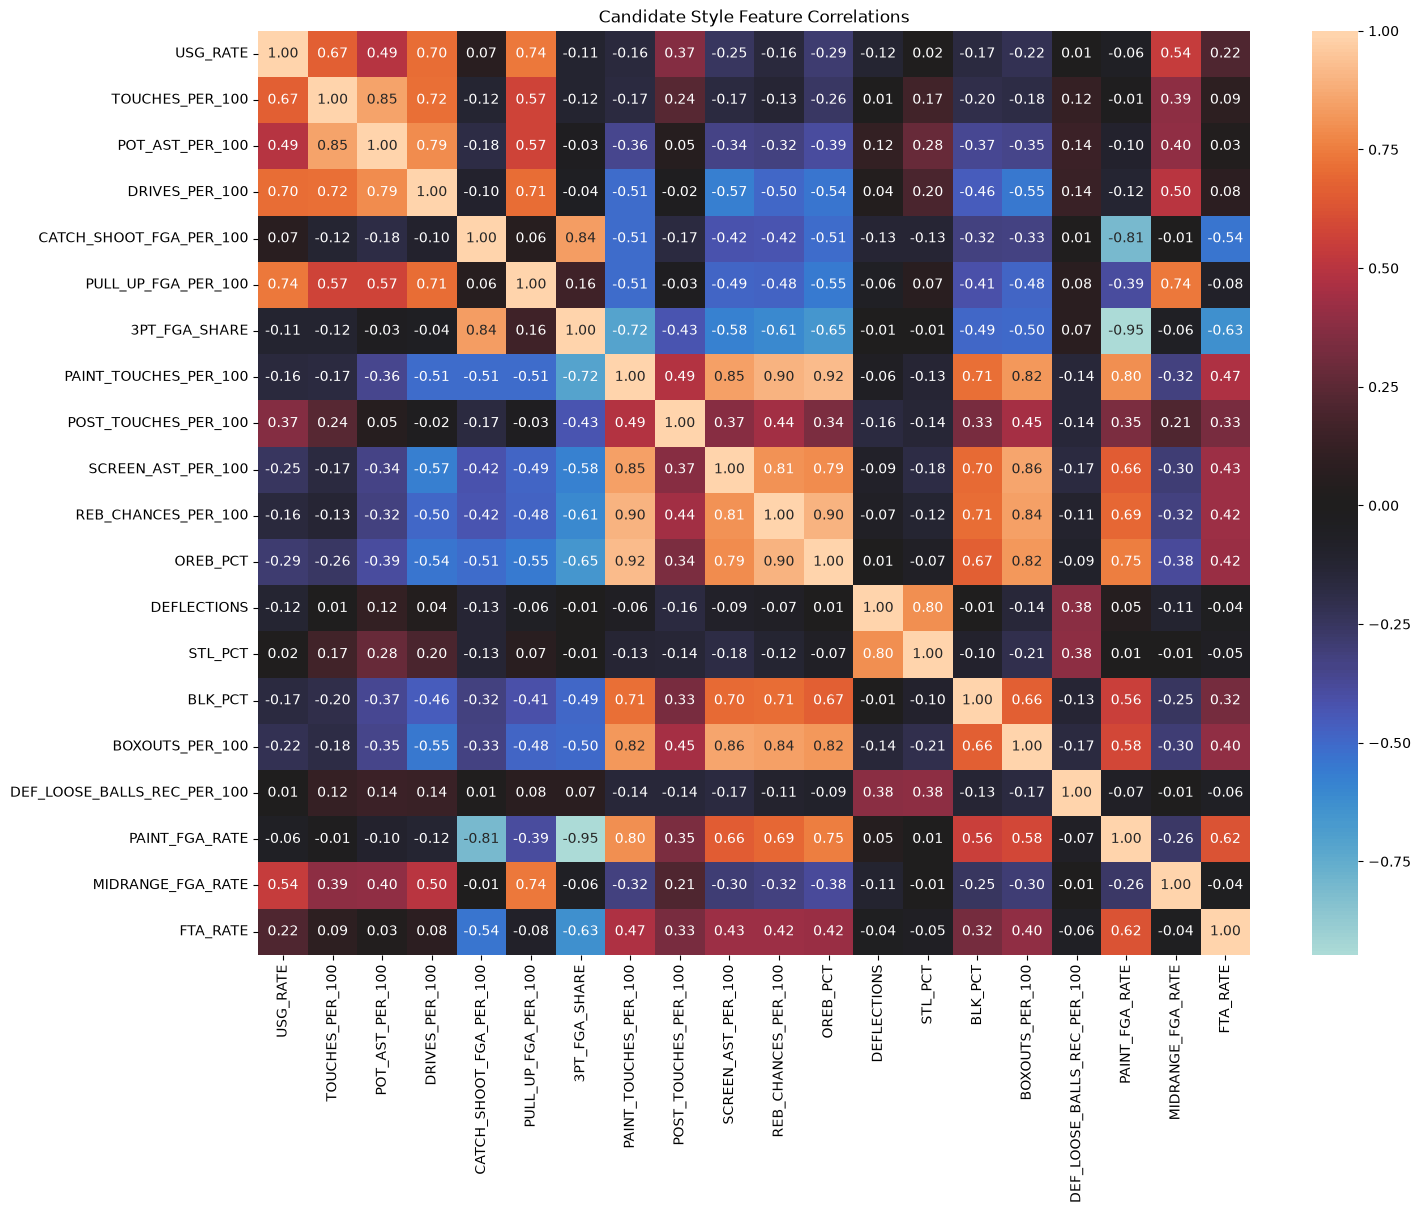

In [52]:
corr = features.corr()

plt.figure(figsize=(16,12))
sns.heatmap(corr, annot=True, fmt=".2f", center=0)
plt.title("Candidate Style Feature Correlations")
plt.show()

In [59]:
feature_names = features.columns.tolist()
strong_corr = []
for i in range(len(feature_names)):
    for j in range(i + 1, len(feature_names)):
        f1 = feature_names[i]
        f2 = feature_names[j]
        r = corr.loc[f1, f2]
        if abs(r) >= 0.85:
            strong_corr.append({"feature 1": f1, "feature 2": f2, "correlation": round(r, 2)})
strong_corr_df = pd.DataFrame(strong_corr)
strong_corr_df.sort_values("correlation", key = abs, ascending = False)

,feature 1,feature 2,correlation
1,3PT_FGA_SHARE,PAINT_FGA_RATE,-0.95
3,PAINT_TOUCHES_PER_100,OREB_PCT,0.92
5,REB_CHANCES_PER_100,OREB_PCT,0.90
2,PAINT_TOUCHES_PER_100,REB_CHANCES_PER_100,0.90
4,SCREEN_AST_PER_100,BOXOUTS_PER_100,0.86
0,TOUCHES_PER_100,POT_AST_PER_100,0.85
